In [5]:
!pip install -U tensorflow



ENVIRONMENT DIAGNOSTICS
Python version    : 3.13.5
Python executable : C:\Users\User\anaconda3\python.exe
TensorFlow        : ✅ available -> 2.20.0

DATA LOADED
Raw shape (after year filter): (1943, 11)
Year range: 1995 to 2023
Countries: 67

PREPROCESSING COMPLETE
Clean shape: (1692, 16)
Median remittance threshold used for treatment: 136212684.1781255
Treatment counts:
 treatment
0    846
1    846

SUMMARY STATISTICS (OVERALL)
                     variable  count               mean                std      min             p25           median              p75                 max
          Personal Remittance   1692 1,058,778,331.6256 3,137,743,338.9194   0.0000 18,458,042.2530 136,212,684.1781 687,384,725.7496 31,487,000,000.0000
               GDP_Per_Capita   1692         5,122.8922        10,893.3698 109.5938        625.6416       1,369.4968       4,167.6601        108,470.3788
              Life_Expectancy   1630            62.6877             9.4563  39.9690         55.7512     

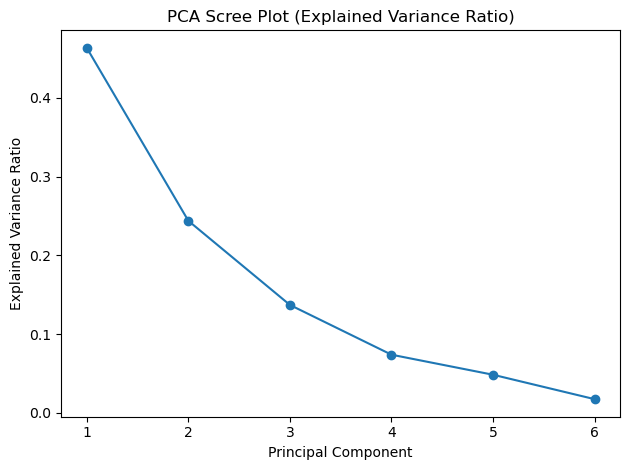

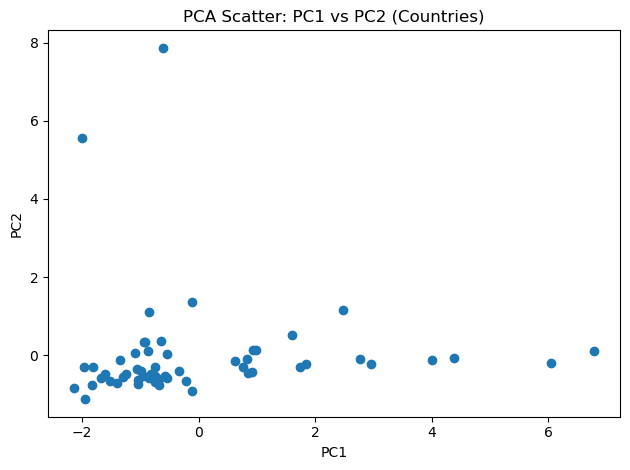

LSTM / ATTENTION-LSTM — Time-series forecasting (TensorFlow)
Epoch 1/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.7855 - val_loss: 0.5811
Epoch 2/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.7845 - val_loss: 0.5820
Epoch 3/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.7845 - val_loss: 0.5817
Epoch 4/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.7810 - val_loss: 0.5823
Epoch 5/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.7816 - val_loss: 0.5828
Epoch 6/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.7844 - val_loss: 0.5834
Epoch 7/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.7809 - val_loss: 0.5831
Epoch 8/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.7810 - val_loss: 0.5831
Epoch 9/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.7791 - val_loss: 0.5844
Epoch 10/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.7812 - val_loss: 0.5835
Epoch 11/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.7787 - val_loss: 0.5835
Epoch 12/50



# Model Card — Remittance, Health & Growth Thesis Pipeline

**Generated:** 2026-01-02 20:23:41  
**Dataset path:** `C:/Users/User/Downloads/Thesis Main Data.xlsx`  
**Year filter:** 1995–2023  
**Unit of analysis:** Country-year panel  
**Outcome:** `GDP_scaled` (z-score of GDP per capita)  
**Treatment:** `treatment = 1` if Remittance > median (136,212,684.1781), else 0

---

## Objective
Predict and analyze GDP per capita (scaled) using remittances and key development indicators, compare against a transparent baseline, evaluate stability with cross-validation, and include causal ATE estimation.

---

## Data Processing
- Dropped rows missing: Year, Country, Remittance, GDP  
- Engineered ratios: `Remit_GDP_Ratio`, `Health_GDP_Ratio` (safe division; inf→NaN)  
- Global z-score scaling: `GDP_scaled`, `remit_scaled`

**Clean dataset shape:** (1692, 16)  
**Modeling dataset rows:** 175

---

## Model Comparison (Holdout Test Set)
| Model | RMSE | MSE | R² |
|---|---:|---:|---:|
| Random Forest | 0.7309 | 0.5342 | 0.7355 |
| Linear Regression (baseline) | 0.8912 | 0.7942 | 0.6068 |

---

## Cross-Validation Stability (5-fold)
**Random Forest:** RMSE 0.7713 ± 0.2983, R² 0.5380 ± 0.3717  
**Linear Regression:** RMSE 0.9714 ± 0.3206, R² 0.4200 ± 0.1441  

---

## Causal Estimate (AIPW)
**ATE on GDP_scaled:** 6.5451  
Meaning: average expected change in GDP_scaled when moving from low to high remittance group (median split), controlling for covariates.

---

## Feature Influence
**Top Random Forest importances**
Life_Expectancy       0.6742
Personal Remittance   0.1167
Physicians_per_1000   0.1081
Literacy_Rate         0.0995
treatment             0.0015

**Top Linear Regression coefficients (abs-ranked)**
Physicians_per_1000    0.8228
treatment             -0.2264
Life_Expectancy        0.1161
Personal Remittance   -0.0318
Literacy_Rate         -0.0074

---

## Artifacts Saved (audit-ready)
- `dataset_cleaned.csv`
- `summary_overall.csv`, `summary_by_country.csv`
- `cross_validation_results.csv`, `holdout_model_comparison.csv`
- `rf_feature_importances.csv`, `linear_regression_coefficients.csv`
- `ate_estimate.csv`
- `pca_explained_variance.csv`, `pca_loadings.csv`
- `test_predictions_rf_vs_linear.csv`
- `lstm_test_predictions.csv`, `attention_lstm_test_predictions.csv`, `lstm_metrics.csv` (if TF available)

**Outputs folder:** `C:\Users\User\thesis_outputs_py`


RUN COMPLETE
Outputs saved in: C:\Users\User\thesis_outputs_py
Recommended GitHub artifacts: notebook + model_card.md + outputs/*.csv + key plots


In [6]:
import os
import sys
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

# Pretty printing options
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# -----------------------------
# 0) CONFIG (EDIT IF NEEDED)
# -----------------------------
DATA_PATH = r"C:/Users/User/Downloads/Thesis Main Data.xlsx"
OUT_DIR = "thesis_outputs_py"
RANDOM_SEED = 2026
SEQ_LEN = 10

np.random.seed(RANDOM_SEED)
os.makedirs(OUT_DIR, exist_ok=True)

# -----------------------------
# 1) ENVIRONMENT DIAGNOSTICS
# -----------------------------
print("\n" + "="*90)
print("ENVIRONMENT DIAGNOSTICS")
print("="*90)
print("Python version    :", sys.version.split()[0])
print("Python executable :", sys.executable)

TF_OK = False
try:
    import tensorflow as tf
    from tensorflow.keras import layers, models
    TF_OK = True
    print("TensorFlow        : ✅ available ->", tf.__version__)
except Exception as e:
    print("TensorFlow        : ❌ NOT available ->", repr(e))
    print("\nIf you just ran: %pip install -U tensorflow")
    print("You may need: Kernel -> Restart Kernel, then re-run this cell.\n")

print("="*90 + "\n")

# -----------------------------
# 2) LOAD DATA
# -----------------------------
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Dataset not found: {DATA_PATH}\n"
        "Fix: update DATA_PATH to the correct full Windows path."
    )

df_raw = pd.read_excel(DATA_PATH, sheet_name=0)

required_cols = [
    "Year",
    "Country Name",
    "Personal Remittance",
    "GDP_Per_Capita",
    "Life_Expectancy",
    "Health_Expenditure_Per_Capita",
    "Literacy_Rate",
    "Physicians_per_1000",
]
missing = [c for c in required_cols if c not in df_raw.columns]
if missing:
    raise KeyError(
        "Missing required columns in your Excel:\n"
        + "\n".join(missing)
        + "\n\nAvailable columns:\n"
        + ", ".join(df_raw.columns.astype(str))
    )

df = df_raw.copy()

# Coerce numeric
numeric_cols = [
    "Year",
    "Personal Remittance",
    "GDP_Per_Capita",
    "Life_Expectancy",
    "Health_Expenditure_Per_Capita",
    "Literacy_Rate",
    "Physicians_per_1000",
]
for c in numeric_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df["Country Name"] = df["Country Name"].astype(str)

# Filter year range
df = df[(df["Year"] >= 1995) & (df["Year"] <= 2023)].copy()

print("="*90)
print("DATA LOADED")
print("="*90)
print("Raw shape (after year filter):", df.shape)
print("Year range:", int(df["Year"].min()), "to", int(df["Year"].max()))
print("Countries:", df["Country Name"].nunique())
print("="*90 + "\n")

# -----------------------------
# 3) PREPROCESSING + FEATURES
# -----------------------------
df_clean = df.dropna(subset=["Year", "Country Name", "Personal Remittance", "GDP_Per_Capita"]).copy()

# Treatment: above median remittance
med_remit = df_clean["Personal Remittance"].median(skipna=True)
df_clean["treatment"] = (df_clean["Personal Remittance"] > med_remit).astype(int)

def safe_div(numer: pd.Series, denom: pd.Series) -> pd.Series:
    denom_safe = denom.replace(0, np.nan)
    return numer / denom_safe

df_clean["Remit_GDP_Ratio"] = safe_div(df_clean["Personal Remittance"], df_clean["GDP_Per_Capita"])
df_clean["Health_GDP_Ratio"] = safe_div(df_clean["Health_Expenditure_Per_Capita"], df_clean["GDP_Per_Capita"])
df_clean.replace([np.inf, -np.inf], np.nan, inplace=True)

# Global z-score scaling
gdp_mean = df_clean["GDP_Per_Capita"].mean()
gdp_std = df_clean["GDP_Per_Capita"].std(ddof=0)
if (not np.isfinite(gdp_std)) or gdp_std == 0:
    gdp_std = 1.0
df_clean["GDP_scaled"] = (df_clean["GDP_Per_Capita"] - gdp_mean) / gdp_std

rem_mean = df_clean["Personal Remittance"].mean()
rem_std = df_clean["Personal Remittance"].std(ddof=0)
if (not np.isfinite(rem_std)) or rem_std == 0:
    rem_std = 1.0
df_clean["remit_scaled"] = (df_clean["Personal Remittance"] - rem_mean) / rem_std

# Save cleaned dataset
df_clean.to_csv(os.path.join(OUT_DIR, "dataset_cleaned.csv"), index=False)

print("="*90)
print("PREPROCESSING COMPLETE")
print("="*90)
print("Clean shape:", df_clean.shape)
print("Median remittance threshold used for treatment:", float(med_remit))
print("Treatment counts:\n", df_clean["treatment"].value_counts().to_string())
print("="*90 + "\n")

# -----------------------------
# 4) SUMMARY STATISTICS (PRINT + SAVE)
# -----------------------------
def describe_numeric(data: pd.DataFrame, cols):
    rows = []
    for c in cols:
        s = pd.to_numeric(data[c], errors="coerce")
        rows.append({
            "variable": c,
            "count": int(s.notna().sum()),
            "mean": float(s.mean()),
            "std": float(s.std(ddof=1)),
            "min": float(s.min()),
            "p25": float(s.quantile(0.25)),
            "median": float(s.quantile(0.50)),
            "p75": float(s.quantile(0.75)),
            "max": float(s.max()),
        })
    return pd.DataFrame(rows)

summary_cols = [
    "Personal Remittance",
    "GDP_Per_Capita",
    "Life_Expectancy",
    "Health_Expenditure_Per_Capita",
    "Literacy_Rate",
    "Physicians_per_1000",
    "Remit_GDP_Ratio",
    "Health_GDP_Ratio",
]
summary_overall = describe_numeric(df_clean, summary_cols)

summary_by_country = (
    df_clean.groupby("Country Name", as_index=False)
    .agg(
        Mean_GDP=("GDP_Per_Capita", "mean"),
        Median_GDP=("GDP_Per_Capita", "median"),
        SD_GDP=("GDP_Per_Capita", "std"),
        Min_GDP=("GDP_Per_Capita", "min"),
        Max_GDP=("GDP_Per_Capita", "max"),
        Mean_Remittance=("Personal Remittance", "mean"),
        Mean_Life_Exp=("Life_Expectancy", "mean"),
        Count=("GDP_Per_Capita", "size"),
    )
    .sort_values("Mean_GDP", ascending=False)
)

summary_overall.to_csv(os.path.join(OUT_DIR, "summary_overall.csv"), index=False)
summary_by_country.to_csv(os.path.join(OUT_DIR, "summary_by_country.csv"), index=False)

print("="*90)
print("SUMMARY STATISTICS (OVERALL)")
print("="*90)
print(summary_overall.to_string(index=False))

print("\n" + "="*90)
print("TOP 10 COUNTRIES BY MEAN GDP PER CAPITA")
print("="*90)
print(summary_by_country.head(10).to_string(index=False))

print("\n" + "="*90)
print("BOTTOM 10 COUNTRIES BY MEAN GDP PER CAPITA")
print("="*90)
print(summary_by_country.tail(10).to_string(index=False))
print("="*90 + "\n")

# -----------------------------
# 5) MODELING SETUP (shared)
# -----------------------------
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def metric_block(name, y_true, y_pred):
    return {
        "model": name,
        "rmse": rmse(y_true, y_pred),
        "mse": float(mean_squared_error(y_true, y_pred)),
        "r2": float(r2_score(y_true, y_pred))
    }

def fmt_mean_std(x):
    x = np.asarray(x)
    return f"{np.mean(x):.4f} ± {np.std(x):.4f}"

rf_features = ["Personal Remittance", "Life_Expectancy", "Literacy_Rate", "Physicians_per_1000", "treatment"]
target_col = "GDP_scaled"

df_model = df_clean.dropna(subset=rf_features + [target_col]).copy()
X = df_model[rf_features]
y = df_model[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED
)

print("="*90)
print("MODEL DATASET READY")
print("="*90)
print("Rows used:", len(df_model))
print("Train rows:", len(X_train), " Test rows:", len(X_test))
print("Features:", rf_features)
print("="*90 + "\n")

# -----------------------------
# 6) CROSS-VALIDATION + BASELINE LINEAR REGRESSION
# -----------------------------
rf_model = RandomForestRegressor(
    n_estimators=500,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    min_samples_leaf=2
)

lin_model = Pipeline([
    ("scaler", StandardScaler()),
    ("linreg", LinearRegression())
])

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
scoring = {"rmse": "neg_root_mean_squared_error", "r2": "r2"}

cv_rf = cross_validate(rf_model, X, y, cv=cv, scoring=scoring, n_jobs=-1)
cv_lin = cross_validate(lin_model, X, y, cv=cv, scoring=scoring, n_jobs=-1)

rf_cv_rmse = -cv_rf["test_rmse"]
lin_cv_rmse = -cv_lin["test_rmse"]

print("="*90)
print("CROSS-VALIDATION RESULTS (5-fold) — Stability")
print("="*90)
print("Random Forest  | RMSE:", fmt_mean_std(rf_cv_rmse), " | R²:", fmt_mean_std(cv_rf["test_r2"]))
print("Linear Reg.    | RMSE:", fmt_mean_std(lin_cv_rmse), " | R²:", fmt_mean_std(cv_lin["test_r2"]))
print("="*90 + "\n")

cv_results_df = pd.DataFrame({
    "fold": np.arange(1, 6),
    "rf_rmse": rf_cv_rmse,
    "rf_r2": cv_rf["test_r2"],
    "lin_rmse": lin_cv_rmse,
    "lin_r2": cv_lin["test_r2"],
})
cv_results_df.to_csv(os.path.join(OUT_DIR, "cross_validation_results.csv"), index=False)

# Fit + holdout comparison
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

lin_model.fit(X_train, y_train)
lin_pred = lin_model.predict(X_test)

rf_metrics = metric_block("Random Forest", y_test, rf_pred)
lin_metrics = metric_block("Linear Regression (baseline)", y_test, lin_pred)

comparison_df = pd.DataFrame([rf_metrics, lin_metrics]).sort_values("rmse")
comparison_df.to_csv(os.path.join(OUT_DIR, "holdout_model_comparison.csv"), index=False)

print("="*90)
print("HOLDOUT TEST SET COMPARISON")
print("="*90)
print(comparison_df.to_string(index=False))
print("="*90 + "\n")

# Feature influence
rf_importances = pd.Series(rf_model.feature_importances_, index=rf_features).sort_values(ascending=False)
lin_coefs = pd.Series(lin_model.named_steps["linreg"].coef_, index=rf_features).sort_values(key=np.abs, ascending=False)

rf_importances.to_csv(os.path.join(OUT_DIR, "rf_feature_importances.csv"), header=["importance"])
lin_coefs.to_csv(os.path.join(OUT_DIR, "linear_regression_coefficients.csv"), header=["coef"])

print("Top RF feature importances:\n", rf_importances.head(10).round(6).to_string())
print("\nTop Linear Regression coefficients (abs-ranked):\n", lin_coefs.head(10).round(6).to_string())
print()

# -----------------------------
# 7) RANDOM FOREST CLASSIFICATION METRICS + ATE PROXY
# -----------------------------
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_cls = (y_test > 0).astype(int)
p_cls = (rf_pred > 0).astype(int)

acc = float(accuracy_score(y_cls, p_cls))
prec = float(precision_score(y_cls, p_cls, zero_division=0))
rec = float(recall_score(y_cls, p_cls, zero_division=0))
f1 = float(f1_score(y_cls, p_cls, zero_division=0))

df_model = df_model.copy()
df_model["rf_pred_all"] = rf_model.predict(df_model[rf_features])
ate_proxy = float(df_model.loc[df_model["treatment"] == 1, "rf_pred_all"].mean()
                  - df_model.loc[df_model["treatment"] == 0, "rf_pred_all"].mean())

print("="*90)
print("RANDOM FOREST: CLASSIFICATION METRICS (threshold GDP_scaled > 0) + ATE PROXY")
print("="*90)
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1       : {f1:.4f}")
print(f"\nATE proxy (RF pred diff treated-control): {ate_proxy:.4f}")
print("="*90 + "\n")

pd.DataFrame({"y_test": y_test.to_numpy(), "rf_pred": rf_pred, "lin_pred": lin_pred}).to_csv(
    os.path.join(OUT_DIR, "test_predictions_rf_vs_linear.csv"), index=False
)

# -----------------------------
# 8) CAUSAL ATE (AIPW)
# -----------------------------
Y = df_model[target_col].to_numpy()
W = df_model["treatment"].to_numpy()
X_causal = df_model[["Personal Remittance", "Life_Expectancy", "Literacy_Rate", "Physicians_per_1000"]].to_numpy()

prop = LogisticRegression(max_iter=500)
prop.fit(X_causal, W)
e = np.clip(prop.predict_proba(X_causal)[:, 1], 1e-3, 1 - 1e-3)

m0 = LinearRegression().fit(X_causal[W == 0], Y[W == 0])
m1 = LinearRegression().fit(X_causal[W == 1], Y[W == 1])
mu0 = m0.predict(X_causal)
mu1 = m1.predict(X_causal)

aipw = (mu1 - mu0) + (W * (Y - mu1) / e) - ((1 - W) * (Y - mu0) / (1 - e))
ate_aipw = float(np.mean(aipw))

print("="*90)
print("CAUSAL EFFECT ESTIMATE (ATE) — AIPW")
print("="*90)
print(f"ATE on GDP_scaled: {ate_aipw:.4f}")
print("Interpretation: average change in GDP_scaled when moving from low to high remittance group (median split).")
print("="*90 + "\n")

pd.DataFrame({"ate_method": ["AIPW"], "ate_value": [ate_aipw]}).to_csv(
    os.path.join(OUT_DIR, "ate_estimate.csv"), index=False
)

# -----------------------------
# 9) PCA (COUNTRY-LEVEL MEANS)
# -----------------------------
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca_cols = [
    "Personal Remittance",
    "GDP_Per_Capita",
    "Life_Expectancy",
    "Health_Expenditure_Per_Capita",
    "Literacy_Rate",
    "Physicians_per_1000",
    "Remit_GDP_Ratio",
    "Health_GDP_Ratio",
]

df_pca = df_clean.dropna(subset=["Country Name"] + pca_cols).copy()
country_agg = df_pca.groupby("Country Name")[pca_cols].mean()
country_agg = country_agg.replace([np.inf, -np.inf], np.nan).dropna(axis=0)

X_pca = StandardScaler().fit_transform(country_agg.values)
pca = PCA(n_components=min(6, X_pca.shape[1]), random_state=RANDOM_SEED)
PC = pca.fit_transform(X_pca)
explained = pca.explained_variance_ratio_

pca_var = pd.DataFrame({
    "PC": [f"PC{i}" for i in range(1, len(explained) + 1)],
    "explained_variance_ratio": explained
})
pca_var.to_csv(os.path.join(OUT_DIR, "pca_explained_variance.csv"), index=False)

loadings = pd.DataFrame(
    pca.components_.T,
    index=pca_cols,
    columns=[f"PC{i}" for i in range(1, pca.n_components_ + 1)]
)
loadings.to_csv(os.path.join(OUT_DIR, "pca_loadings.csv"))

print("="*90)
print("PCA RESULTS (Country-level means)")
print("="*90)
print(pca_var.to_string(index=False))
print("\nTop loadings (absolute) for PC1:")
print(loadings["PC1"].abs().sort_values(ascending=False).head(8).to_string())
print("="*90 + "\n")

plt.figure()
plt.plot(np.arange(1, len(explained) + 1), explained, marker="o")
plt.title("PCA Scree Plot (Explained Variance Ratio)")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "pca_scree_plot.png"), dpi=200)
plt.show()

pc_df = pd.DataFrame(PC[:, :2], columns=["PC1", "PC2"], index=country_agg.index).reset_index().rename(columns={"index": "Country"})
plt.figure()
plt.scatter(pc_df["PC1"], pc_df["PC2"])
plt.title("PCA Scatter: PC1 vs PC2 (Countries)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "pca_pc1_pc2_scatter.png"), dpi=200)
plt.show()

# -----------------------------
# 10) LSTM + ATTENTION-LSTM (Time-series forecasting)
# -----------------------------
def build_sequences(panel: pd.DataFrame, seq_len: int = 10):
    X_list, y_list = [], []
    for _, g in panel.groupby("Country Name"):
        g = g.sort_values("Year")
        if len(g) < seq_len + 1:
            continue
        rem = g["remit_scaled"].to_numpy()
        y = g["GDP_scaled"].to_numpy()
        for i in range(0, len(g) - seq_len):
            x_win = rem[i:i + seq_len]
            y_tgt = y[i + seq_len]
            if np.isfinite(x_win).all() and np.isfinite(y_tgt):
                X_list.append(x_win.reshape(seq_len, 1))
                y_list.append(y_tgt)
    if len(X_list) == 0:
        return None, None
    return np.stack(X_list).astype(np.float32), np.array(y_list, dtype=np.float32)

if TF_OK:
    print("="*90)
    print("LSTM / ATTENTION-LSTM — Time-series forecasting (TensorFlow)")
    print("="*90)

    # Build sequences by country: past 10 years remittance -> next year GDP
    df_lstm = df_clean.dropna(subset=["Country Name", "Year", "remit_scaled", "GDP_scaled"]).copy()
    df_lstm = df_lstm.sort_values(["Country Name", "Year"])
    X_seq, y_seq = build_sequences(df_lstm, seq_len=SEQ_LEN)

    if X_seq is None:
        print("⚠️ No valid sequences created (not enough consecutive years per country). LSTM skipped.")
    else:
        X_lstm_train, X_lstm_test, y_lstm_train, y_lstm_test = train_test_split(
            X_seq, y_seq, test_size=0.2, random_state=RANDOM_SEED
        )

        tf.random.set_seed(RANDOM_SEED)

        # ----- LSTM -----
        lstm_model = models.Sequential([
            layers.Input(shape=(SEQ_LEN, 1)),
            layers.LSTM(50, return_sequences=False),
            layers.Dropout(0.2),
            layers.Dense(1)
        ])
        lstm_model.compile(optimizer="adam", loss="mse")
        lstm_model.fit(
            X_lstm_train, y_lstm_train,
            epochs=50,
            batch_size=16,
            validation_split=0.1,
            verbose=1
        )

        lstm_pred = lstm_model.predict(X_lstm_test).reshape(-1)
        lstm_rmse = rmse(y_lstm_test, lstm_pred)
        lstm_r2 = float(r2_score(y_lstm_test, lstm_pred))

        print(f"\nLSTM Results: RMSE={lstm_rmse:.4f}  R²={lstm_r2:.4f}")

        pd.DataFrame({"y_lstm_test": y_lstm_test, "lstm_pred": lstm_pred}).to_csv(
            os.path.join(OUT_DIR, "lstm_test_predictions.csv"), index=False
        )

        # ----- Attention-LSTM -----
        class Attention(layers.Layer):
            def build(self, input_shape):
                self.W = self.add_weight(shape=(input_shape[-1], 1),
                                         initializer="glorot_uniform",
                                         trainable=True)
                self.b = self.add_weight(shape=(input_shape[1], 1),
                                         initializer="zeros",
                                         trainable=True)
                super().build(input_shape)

            def call(self, x):
                scores = tf.tensordot(x, self.W, axes=1) + self.b
                weights = tf.nn.softmax(scores, axis=1)
                context = tf.reduce_sum(x * weights, axis=1)
                return context

        inp = layers.Input(shape=(SEQ_LEN, 1))
        x = layers.LSTM(64, return_sequences=True)(inp)
        ctx = Attention()(x)
        ctx = layers.Dropout(0.2)(ctx)
        out = layers.Dense(1)(ctx)

        att_model = models.Model(inp, out)
        att_model.compile(optimizer="adam", loss="mse")
        att_model.fit(
            X_lstm_train, y_lstm_train,
            epochs=50,
            batch_size=16,
            validation_split=0.1,
            verbose=1
        )

        att_pred = att_model.predict(X_lstm_test).reshape(-1)
        att_rmse = rmse(y_lstm_test, att_pred)
        att_r2 = float(r2_score(y_lstm_test, att_pred))

        print(f"Attention-LSTM Results: RMSE={att_rmse:.4f}  R²={att_r2:.4f}")

        pd.DataFrame({"y_lstm_test": y_lstm_test, "att_pred": att_pred}).to_csv(
            os.path.join(OUT_DIR, "attention_lstm_test_predictions.csv"), index=False
        )

        # Save LSTM metrics summary
        pd.DataFrame([
            {"model": "LSTM", "rmse": lstm_rmse, "r2": lstm_r2},
            {"model": "Attention-LSTM", "rmse": att_rmse, "r2": att_r2},
        ]).to_csv(os.path.join(OUT_DIR, "lstm_metrics.csv"), index=False)

    print("="*90 + "\n")
else:
    print("="*90)
    print("LSTM / ATTENTION-LSTM SKIPPED — TensorFlow not available in this kernel.")
    print("You requested pip install tensorflow. Run this at the top of the notebook:")
    print("  %pip install -U tensorflow")
    print("Then restart kernel and rerun.")
    print("="*90 + "\n")

# -----------------------------
# 11) MODEL CARD (one-page)
# -----------------------------
from datetime import datetime
from IPython.display import display, Markdown

now = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

model_card_md = f"""
# Model Card — Remittance, Health & Growth Thesis Pipeline

**Generated:** {now}  
**Dataset path:** `{DATA_PATH}`  
**Year filter:** 1995–2023  
**Unit of analysis:** Country-year panel  
**Outcome:** `GDP_scaled` (z-score of GDP per capita)  
**Treatment:** `treatment = 1` if Remittance > median ({float(med_remit):,.4f}), else 0

---

## Objective
Predict and analyze GDP per capita (scaled) using remittances and key development indicators, compare against a transparent baseline, evaluate stability with cross-validation, and include causal ATE estimation.

---

## Data Processing
- Dropped rows missing: Year, Country, Remittance, GDP  
- Engineered ratios: `Remit_GDP_Ratio`, `Health_GDP_Ratio` (safe division; inf→NaN)  
- Global z-score scaling: `GDP_scaled`, `remit_scaled`

**Clean dataset shape:** {df_clean.shape}  
**Modeling dataset rows:** {len(df_model):,}

---

## Model Comparison (Holdout Test Set)
| Model | RMSE | MSE | R² |
|---|---:|---:|---:|
| Random Forest | {rf_metrics["rmse"]:.4f} | {rf_metrics["mse"]:.4f} | {rf_metrics["r2"]:.4f} |
| Linear Regression (baseline) | {lin_metrics["rmse"]:.4f} | {lin_metrics["mse"]:.4f} | {lin_metrics["r2"]:.4f} |

---

## Cross-Validation Stability (5-fold)
**Random Forest:** RMSE {fmt_mean_std(rf_cv_rmse)}, R² {fmt_mean_std(cv_rf["test_r2"])}  
**Linear Regression:** RMSE {fmt_mean_std(lin_cv_rmse)}, R² {fmt_mean_std(cv_lin["test_r2"])}  

---

## Causal Estimate (AIPW)
**ATE on GDP_scaled:** {ate_aipw:.4f}  
Meaning: average expected change in GDP_scaled when moving from low to high remittance group (median split), controlling for covariates.

---

## Feature Influence
**Top Random Forest importances**
{rf_importances.head(8).round(6).to_string()}

**Top Linear Regression coefficients (abs-ranked)**
{lin_coefs.head(8).round(6).to_string()}

---

## Artifacts Saved (audit-ready)
- `dataset_cleaned.csv`
- `summary_overall.csv`, `summary_by_country.csv`
- `cross_validation_results.csv`, `holdout_model_comparison.csv`
- `rf_feature_importances.csv`, `linear_regression_coefficients.csv`
- `ate_estimate.csv`
- `pca_explained_variance.csv`, `pca_loadings.csv`
- `test_predictions_rf_vs_linear.csv`
- `lstm_test_predictions.csv`, `attention_lstm_test_predictions.csv`, `lstm_metrics.csv` (if TF available)

**Outputs folder:** `{os.path.abspath(OUT_DIR)}`
"""

display(Markdown(model_card_md))
with open(os.path.join(OUT_DIR, "model_card.md"), "w", encoding="utf-8") as f:
    f.write(model_card_md)

print("="*90)
print("RUN COMPLETE")
print("="*90)
print("Outputs saved in:", os.path.abspath(OUT_DIR))
print("Recommended GitHub artifacts: notebook + model_card.md + outputs/*.csv + key plots")
print("="*90)


In [7]:
import os
import re
import sys
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# -----------------------------
# 0) CONFIG (EDIT IF NEEDED)
# -----------------------------
OUT_DIR = r"C:\Users\User\thesis_outputs_py"     # your outputs folder
os.makedirs(OUT_DIR, exist_ok=True)

# Optional: point to a file that contains NLP text
# - If you have an Excel/CSV with text column, set it here:
NLP_DATA_PATH = None
# Examples:
# NLP_DATA_PATH = r"C:\Users\User\Downloads\policy_texts.xlsx"
# NLP_DATA_PATH = r"C:\Users\User\Downloads\policy_texts.csv"

# Column names (script will try to auto-detect if you don't match exactly)
TEXT_COL_CANDIDATES  = ["Policy_Text", "Text", "text", "policy_text", "document", "Document"]
LABEL_COL_CANDIDATES = ["Sentiment", "Label", "label", "Class", "class", "category", "Category"]

RANDOM_SEED = 2026
np.random.seed(RANDOM_SEED)

print("\n" + "="*90)
print("NLP PIPELINE START")
print("="*90)
print("Python:", sys.version.split()[0])
print("Executable:", sys.executable)
print("OUT_DIR:", OUT_DIR)
print("="*90 + "\n")

# -----------------------------
# 1) LOAD NLP DATA (from file OR fallback sample)
# -----------------------------
def find_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    # try case-insensitive match
    lower_map = {col.lower(): col for col in df.columns}
    for c in candidates:
        if c.lower() in lower_map:
            return lower_map[c.lower()]
    return None

def load_nlp_data(path):
    if path is None:
        return None
    if not os.path.exists(path):
        raise FileNotFoundError(f"NLP_DATA_PATH not found: {path}")

    ext = os.path.splitext(path)[1].lower()
    if ext in [".xlsx", ".xls"]:
        # Read first sheet
        return pd.read_excel(path, sheet_name=0)
    elif ext == ".csv":
        return pd.read_csv(path)
    else:
        raise ValueError("Unsupported file type. Use .xlsx/.xls or .csv")

# Try file load
df_nlp = load_nlp_data(NLP_DATA_PATH)

# If no file provided, use a clean sample (recruiter-friendly)
if df_nlp is None:
    df_nlp = pd.DataFrame({
        "Country": ["Nigeria", "Kenya", "Ghana", "South Africa", "Uganda"],
        "Policy_Text": [
            "Nigeria received the largest nominal inflow just under 24 billion dollars in 2019. Policies focus on improving formal channels.",
            "Kenya has strong diaspora engagement and initiatives to reduce remittance transaction costs and improve inclusion.",
            "Ghana supports remittance inflows through diaspora bonds and initiatives to formalize transfers and reduce barriers.",
            "South Africa plays a central role in regional remittance corridors and focuses on compliance while supporting formal channels.",
            "Remittances are important for low-income countries, yet regulatory burdens may increase costs and reduce access."
        ]
    })
    print("⚠️ NLP_DATA_PATH not provided -> using built-in SAMPLE text dataset.\n"
          "If you have your own text dataset, set NLP_DATA_PATH to your Excel/CSV.\n")

text_col = find_col(df_nlp, TEXT_COL_CANDIDATES)
label_col = find_col(df_nlp, LABEL_COL_CANDIDATES)

if text_col is None:
    raise KeyError(
        "Could not find a text column.\n"
        f"Looked for: {TEXT_COL_CANDIDATES}\n"
        f"Columns found: {list(df_nlp.columns)}\n"
        "Fix: rename your text column to Policy_Text or Text."
    )

print("="*90)
print("DATA LOADED")
print("="*90)
print("Shape:", df_nlp.shape)
print("Text column detected:", text_col)
print("Label column detected:", label_col if label_col else "(None -> will run UNSUPERVISED mode)")
print("="*90 + "\n")

# -----------------------------
# 2) TEXT CLEANING
# -----------------------------
def clean_text(s: str) -> str:
    if not isinstance(s, str):
        s = "" if pd.isna(s) else str(s)
    s = s.lower()
    s = re.sub(r"http\S+|www\.\S+", " ", s)            # remove urls
    s = re.sub(r"[^a-z0-9\s']", " ", s)               # keep letters/numbers/apostrophe
    s = re.sub(r"\s+", " ", s).strip()                # normalize whitespace
    return s

df_nlp = df_nlp.copy()
df_nlp["text_clean"] = df_nlp[text_col].astype(str).map(clean_text)

# Remove empty docs
df_nlp = df_nlp[df_nlp["text_clean"].str.len() > 0].copy()

print("="*90)
print("TEXT CLEANING COMPLETE")
print("="*90)
print(df_nlp[[text_col, "text_clean"]].head(5).to_string(index=False))
print("="*90 + "\n")

# Save cleaned text
df_nlp.to_csv(os.path.join(OUT_DIR, "nlp_cleaned_text.csv"), index=False)

# -----------------------------
# 3) COMMON NLP: TF-IDF KEYWORDS
# -----------------------------
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=1,
    max_df=0.95
)

X_tfidf = tfidf.fit_transform(df_nlp["text_clean"])
feature_names = np.array(tfidf.get_feature_names_out())

# Top keywords overall
tfidf_sum = np.asarray(X_tfidf.sum(axis=0)).ravel()
top_idx = tfidf_sum.argsort()[::-1][:25]
top_terms = pd.DataFrame({
    "term": feature_names[top_idx],
    "tfidf_weight_sum": tfidf_sum[top_idx]
})

print("="*90)
print("TOP TF-IDF KEYWORDS (Overall)")
print("="*90)
print(top_terms.to_string(index=False))
print("="*90 + "\n")

top_terms.to_csv(os.path.join(OUT_DIR, "nlp_top_tfidf_terms.csv"), index=False)

# -----------------------------
# 4) UNSUPERVISED MODE (if no labels)
# - Topic Modeling (NMF)
# - Sentiment (VADER if available, else simple lexicon fallback)
# -----------------------------
def run_unsupervised(df):
    print("="*90)
    print("UNSUPERVISED NLP MODE")
    print("="*90)

    # --- Topic modeling using NMF ---
    from sklearn.decomposition import NMF

    n_topics = min(5, max(2, df.shape[0] // 2))  # safe heuristic
    nmf = NMF(n_components=n_topics, random_state=RANDOM_SEED, init="nndsvd", max_iter=500)
    W = nmf.fit_transform(X_tfidf)
    H = nmf.components_

    def top_words_for_topic(topic_idx, n=10):
        inds = H[topic_idx].argsort()[::-1][:n]
        return ", ".join(feature_names[inds])

    topics = []
    for k in range(n_topics):
        topics.append({"topic": f"Topic_{k+1}", "top_terms": top_words_for_topic(k, n=12)})

    topics_df = pd.DataFrame(topics)
    topics_df.to_csv(os.path.join(OUT_DIR, "nlp_topics_nmf.csv"), index=False)

    # Assign dominant topic per document
    dom_topic = W.argmax(axis=1) + 1
    df_out = df.copy()
    df_out["dominant_topic"] = dom_topic
    df_out.to_csv(os.path.join(OUT_DIR, "nlp_docs_with_topics.csv"), index=False)

    print("\nTopics discovered (NMF):")
    print(topics_df.to_string(index=False))
    print("\nSaved: nlp_topics_nmf.csv, nlp_docs_with_topics.csv")

    # --- Sentiment scoring ---
    sentiment_method = None
    try:
        import nltk
        from nltk.sentiment import SentimentIntensityAnalyzer
        try:
            nltk.data.find("sentiment/vader_lexicon.zip")
        except LookupError:
            nltk.download("vader_lexicon")
        sia = SentimentIntensityAnalyzer()

        df_out["sentiment_compound"] = df_out["text_clean"].map(lambda x: sia.polarity_scores(x)["compound"])
        sentiment_method = "VADER"
    except Exception:
        # fallback: extremely simple lexicon (safe, no extra installs)
        positive = set(["support", "improve", "reduce", "benefit", "strong", "increase", "inclusion", "formalize", "initiative", "engagement"])
        negative = set(["restrict", "burden", "cost", "barrier", "discourage", "monitoring", "compliance", "risk"])
        def simple_sent(x):
            toks = x.split()
            if not toks:
                return 0.0
            score = sum(t in positive for t in toks) - sum(t in negative for t in toks)
            return score / max(1, len(toks))
        df_out["sentiment_compound"] = df_out["text_clean"].map(simple_sent)
        sentiment_method = "SimpleLexicon"

    # Bucket sentiment
    df_out["sentiment_label"] = pd.cut(
        df_out["sentiment_compound"],
        bins=[-1.01, -0.05, 0.05, 1.01],
        labels=["negative", "neutral", "positive"]
    )

    df_out.to_csv(os.path.join(OUT_DIR, "nlp_sentiment_scored.csv"), index=False)

    print("\nSentiment method used:", sentiment_method)
    print(df_out[["sentiment_compound", "sentiment_label"]].describe().to_string())
    print("\nSentiment label counts:\n", df_out["sentiment_label"].value_counts().to_string())
    print("\nSaved: nlp_sentiment_scored.csv")

    return topics_df, df_out, sentiment_method

# -----------------------------
# 5) SUPERVISED MODE (if labels exist)
# - TF-IDF -> Logistic Regression (strong baseline)
# - Cross-validation + holdout evaluation
# - Confusion matrix and top features per class
# -----------------------------
def run_supervised(df, label_col):
    print("="*90)
    print("SUPERVISED NLP MODE")
    print("="*90)

    from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
    from sklearn.pipeline import Pipeline
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

    # Clean label column
    df_sup = df.dropna(subset=[label_col]).copy()
    df_sup[label_col] = df_sup[label_col].astype(str).str.strip().str.lower()

    # Basic sanity
    if df_sup[label_col].nunique() < 2:
        raise ValueError(f"Need at least 2 classes in {label_col} for supervised learning.")

    X_text = df_sup["text_clean"]
    y = df_sup[label_col]

    X_train, X_test, y_train, y_test = train_test_split(
        X_text, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
    )

    clf = Pipeline([
        ("tfidf", TfidfVectorizer(stop_words="english", ngram_range=(1,2), max_df=0.95, min_df=1)),
        ("logreg", LogisticRegression(max_iter=2000))
    ])

    # Cross-validation
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
    cv_scores = cross_validate(clf, X_text, y, cv=cv, scoring=["accuracy", "f1_macro"])

    cv_df = pd.DataFrame({
        "fold": np.arange(1, 6),
        "accuracy": cv_scores["test_accuracy"],
        "f1_macro": cv_scores["test_f1_macro"]
    })
    cv_df.to_csv(os.path.join(OUT_DIR, "nlp_cv_results.csv"), index=False)

    print("\nCross-validation (5-fold):")
    print("Accuracy:  ", f"{cv_df['accuracy'].mean():.4f} ± {cv_df['accuracy'].std():.4f}")
    print("F1-macro:  ", f"{cv_df['f1_macro'].mean():.4f} ± {cv_df['f1_macro'].std():.4f}")

    # Fit + evaluate
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)

    acc = accuracy_score(y_test, preds)
    print("\nHoldout Test Accuracy:", f"{acc:.4f}")
    print("\nClassification Report:\n", classification_report(y_test, preds))

    cm = confusion_matrix(y_test, preds, labels=sorted(y.unique()))
    cm_df = pd.DataFrame(cm, index=[f"true_{c}" for c in sorted(y.unique())],
                         columns=[f"pred_{c}" for c in sorted(y.unique())])
    cm_df.to_csv(os.path.join(OUT_DIR, "nlp_confusion_matrix.csv"), index=True)

    # Save predictions
    pred_df = pd.DataFrame({"text": X_test.values, "true": y_test.values, "pred": preds})
    pred_df.to_csv(os.path.join(OUT_DIR, "nlp_holdout_predictions.csv"), index=False)

    print("\nConfusion matrix saved: nlp_confusion_matrix.csv")
    print("Holdout predictions saved: nlp_holdout_predictions.csv")

    # Top features per class (logreg)
    vec = clf.named_steps["tfidf"]
    model = clf.named_steps["logreg"]

    feat = np.array(vec.get_feature_names_out())
    if len(model.classes_) == 2:
        # binary: coefficients correspond to class 1
        coefs = model.coef_[0]
        top_pos = feat[np.argsort(coefs)[-15:]][::-1]
        top_neg = feat[np.argsort(coefs)[:15]]
        top_features_df = pd.DataFrame({
            "top_positive_class_terms": pd.Series(top_pos),
            "top_negative_class_terms": pd.Series(top_neg)
        })
    else:
        rows = []
        for i, cls in enumerate(model.classes_):
            coefs = model.coef_[i]
            top_terms = feat[np.argsort(coefs)[-15:]][::-1]
            rows.append({"class": cls, "top_terms": ", ".join(top_terms)})
        top_features_df = pd.DataFrame(rows)

    top_features_df.to_csv(os.path.join(OUT_DIR, "nlp_top_features.csv"), index=False)
    print("Top features saved: nlp_top_features.csv")

    # Return objects for model card
    results = {
        "cv_accuracy_mean": float(cv_df["accuracy"].mean()),
        "cv_accuracy_std": float(cv_df["accuracy"].std()),
        "cv_f1_mean": float(cv_df["f1_macro"].mean()),
        "cv_f1_std": float(cv_df["f1_macro"].std()),
        "holdout_accuracy": float(acc),
        "classes": sorted(y.unique()),
        "n_rows": int(df_sup.shape[0]),
        "n_classes": int(y.nunique())
    }
    return results

# -----------------------------
# 6) RUN MODE
# -----------------------------
if label_col:
    sup_results = run_supervised(df_nlp, label_col)
    mode = "supervised"
    unsup_outputs = None
else:
    topics_df, sentiment_df, sentiment_method = run_unsupervised(df_nlp)
    mode = "unsupervised"
    sup_results = None
    unsup_outputs = {"sentiment_method": sentiment_method, "n_topics": int(topics_df.shape[0])}

# -----------------------------
# 7) MODEL CARD (NLP one-page) + Save
# -----------------------------
from datetime import datetime

now = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

if mode == "supervised":
    model_card = f"""
# NLP Model Card — Thesis NLP Module

**Generated:** {now}  
**Mode:** Supervised Text Classification  
**Text column:** {text_col}  
**Label column:** {label_col}  
**Rows used (labeled):** {sup_results["n_rows"]:,}  
**Classes:** {", ".join(sup_results["classes"])}  

---

## Objective
Classify remittance policy / narrative text into sentiment categories using TF-IDF features and Logistic Regression.

---

## Model
- **Vectorizer:** TF-IDF (unigrams + bigrams, English stopwords)
- **Classifier:** Logistic Regression

---

## Performance
- **5-fold CV Accuracy:** {sup_results["cv_accuracy_mean"]:.4f} ± {sup_results["cv_accuracy_std"]:.4f}
- **5-fold CV F1-macro:** {sup_results["cv_f1_mean"]:.4f} ± {sup_results["cv_f1_std"]:.4f}
- **Holdout Accuracy:** {sup_results["holdout_accuracy"]:.4f}

---

## Artifacts Saved
- `nlp_cleaned_text.csv`
- `nlp_top_tfidf_terms.csv`
- `nlp_cv_results.csv`
- `nlp_confusion_matrix.csv`
- `nlp_holdout_predictions.csv`
- `nlp_top_features.csv`
"""
else:
    model_card = f"""
# NLP Model Card — Thesis NLP Module

**Generated:** {now}  
**Mode:** Unsupervised NLP (Topics + Sentiment)  
**Text column:** {text_col}  
**Rows used:** {df_nlp.shape[0]:,}  
**Sentiment method:** {unsup_outputs["sentiment_method"]}  
**Topics (NMF):** {unsup_outputs["n_topics"]}  

---

## Objective
Extract themes and sentiment signals from remittance-related text when no ground-truth labels are available.

---

## Methods
- **TF-IDF:** identify highest-signal terms
- **Topic Modeling:** NMF over TF-IDF (dominant topic per document)
- **Sentiment:** VADER if available; otherwise a safe lexicon fallback

---

## Artifacts Saved
- `nlp_cleaned_text.csv`
- `nlp_top_tfidf_terms.csv`
- `nlp_topics_nmf.csv`
- `nlp_docs_with_topics.csv`
- `nlp_sentiment_scored.csv`
"""

model_card_path = os.path.join(OUT_DIR, "nlp_model_card.md")
with open(model_card_path, "w", encoding="utf-8") as f:
    f.write(model_card.strip())

print("\n" + "="*90)
print("NLP RUN COMPLETE")
print("="*90)
print("Mode:", mode)
print("Saved outputs to:", OUT_DIR)
print("Key NLP files:")
print(" - nlp_cleaned_text.csv")
print(" - nlp_top_tfidf_terms.csv")
print(" - nlp_model_card.md")
if mode == "supervised":
    print(" - nlp_cv_results.csv")
    print(" - nlp_confusion_matrix.csv")
    print(" - nlp_holdout_predictions.csv")
    print(" - nlp_top_features.csv")
else:
    print(" - nlp_topics_nmf.csv")
    print(" - nlp_docs_with_topics.csv")
    print(" - nlp_sentiment_scored.csv")
print("="*90)



NLP PIPELINE START
Python: 3.13.5
Executable: C:\Users\User\anaconda3\python.exe
OUT_DIR: C:\Users\User\thesis_outputs_py

⚠️ NLP_DATA_PATH not provided -> using built-in SAMPLE text dataset.
If you have your own text dataset, set NLP_DATA_PATH to your Excel/CSV.

DATA LOADED
Shape: (5, 2)
Text column detected: Policy_Text
Label column detected: (None -> will run UNSUPERVISED mode)

TEXT CLEANING COMPLETE
                                                                                                                    Policy_Text                                                                                                                    text_clean
Nigeria received the largest nominal inflow just under 24 billion dollars in 2019. Policies focus on improving formal channels. nigeria received the largest nominal inflow just under 24 billion dollars in 2019 policies focus on improving formal channels
             Kenya has strong diaspora engagement and initiatives to reduce remitt

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...



Sentiment method used: VADER
       sentiment_compound
count              5.0000
mean               0.4204
std                0.3603
min               -0.1280
25%                0.3612
50%                0.4215
75%                0.5994
max                0.8481

Sentiment label counts:
 sentiment_label
positive    4
negative    1
neutral     0

Saved: nlp_sentiment_scored.csv

NLP RUN COMPLETE
Mode: unsupervised
Saved outputs to: C:\Users\User\thesis_outputs_py
Key NLP files:
 - nlp_cleaned_text.csv
 - nlp_top_tfidf_terms.csv
 - nlp_model_card.md
 - nlp_topics_nmf.csv
 - nlp_docs_with_topics.csv
 - nlp_sentiment_scored.csv
